In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import numpy as np
import os
import copy
import random
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from torch_geometric.data import HeteroData, Batch
from torch_geometric.nn import HeteroConv, TransformerConv
from data_utils import haversine
from model_graph_transformer import GraphTransformerReg as GraphTransformer
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
if torch.cuda.is_available():
  torch.cuda.manual_seed(42)
  torch.cuda.manual_seed_all(42)
np.random.seed(42)
random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")



Using device: cuda


## Configuration

Constants and hyperparameters for training the Graph Transformer model for link prediction task

In [3]:
args = {
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'hidden_size': 64,
    'epochs': 100,
    'weight_decay': 1e-4,
    'lr': 5e-4,
    'num_heads': 4,
    'num_layers': 2,
    'dropout': 0.1,
    'batch_size': 32
}

## Data Loading and Preprocessing


In [4]:
class GraphBuilder:
    """Build and cache heterogeneous graphs for each timestamp"""
    def __init__(self, filepath):
        self.filepath = filepath
        self.spatial_scaler = StandardScaler()
        self.time_scaler = StandardScaler()
        self.df = None
        self.spatial_features = None
        self.spatial_nodes = None
        self.radius_to_idx = None
        self.spatial_edges = None
        self.spatial_edge_weights = None
        self.all_months = None
        
    def load_and_preprocess(self):
        """Load data and create static components"""
        print("Loading data...")
        self.df = pd.read_excel(self.filepath)
        self.df['event_month'] = (self.df['event_time'] * 12).astype(int)
        self.df = self.df.sort_values('event_month').reset_index(drop=True)
        
        # Get all unique months
        self.all_months = sorted(self.df['event_month'].unique())
        
        # Create spatial nodes (static)
        self.spatial_nodes = self.df.groupby('fault_radius').agg({
            'magnitude': 'mean',
            'latitude': 'mean',
            'longitude': 'mean',
            'depth': 'mean'
        }).reset_index()
        
        self.radius_to_idx = {radius: idx for idx, radius in enumerate(self.spatial_nodes['fault_radius'])}
        
        features = self.spatial_nodes[['magnitude', 'latitude', 'longitude', 'depth']].values
        self.spatial_features = torch.FloatTensor(self.spatial_scaler.fit_transform(features))
        
        # Create spatial-spatial edges with weights
        self.spatial_edges, self.spatial_edge_weights = self._create_spatial_edges()
        
        print(f"Loaded {len(self.spatial_nodes)} spatial nodes, {self.spatial_edges.shape[1]} spatial edges, {len(self.all_months)} time steps")
        
    def _create_spatial_edges(self):
        """Create edges between all spatial nodes with distance as weights"""
        n = len(self.spatial_nodes)
        edge_index = [[], []]
        edge_weights = []
        
        for i in range(n):
            for j in range(i+1, n):
                lat1, lon1 = self.spatial_nodes.iloc[i]['latitude'], self.spatial_nodes.iloc[i]['longitude']
                lat2, lon2 = self.spatial_nodes.iloc[j]['latitude'], self.spatial_nodes.iloc[j]['longitude']
                
                dist = haversine(lon1, lat1, lon2, lat2)
                
                # Add edges in both directions
                edge_index[0].extend([i, j])
                edge_index[1].extend([j, i])
                # Add weight for both directions
                edge_weights.extend([dist, dist])
        edge_weights = torch.FloatTensor(edge_weights)
        max_dist = torch.max(edge_weights)
        edge_weights = 1 - (edge_weights / max_dist + 1e-8)  # Normalize to [0, 1] and invert (closer -> higher weight)
        
        return torch.LongTensor(edge_index), edge_weights
    
    def create_time_features(self, months):
        time_features = []
        for month in months:
            sin_month = np.sin(2 * np.pi * (month / 12))
            cos_month = np.cos(2 * np.pi * (month / 12))
            time_features.append([sin_month, cos_month, month / 12])
        
        time_features = np.array(time_features)
        return torch.FloatTensor(self.time_scaler.fit_transform(time_features))
    
    def build_graph_up_to_month(self, cutoff_month, target_month):
        """Build heterogeneous graph with all data up to cutoff_month"""
        # Filter data up to cutoff
        past_df = self.df[self.df['event_month'] <= cutoff_month]
        past_months = [i for i in range(target_month + 1)]
        
        # Create time features
        time_features = self.create_time_features(past_months)
        
        # Create spatial-time edges with earthquake magnitude as edge weight
        st_edge_index = [[], []]
        st_edge_weights = []  
        for _, row in past_df.iterrows():
            if row['fault_radius'] in self.radius_to_idx:
                spatial_idx = self.radius_to_idx[row['fault_radius']]
                time_idx = row['event_month']
                st_edge_index[1].append(spatial_idx)
                st_edge_index[0].append(time_idx)
                st_edge_weights.append(row['magnitude'])
        
        # Normalize spatial-time edge weights
        st_edge_weights = torch.FloatTensor(st_edge_weights)
        st_edge_weights = (st_edge_weights - st_edge_weights.min()) / (st_edge_weights.max() - st_edge_weights.min() + 1e-8)
        
        # Create time edges with weight 1
        time_index = [[], []]
        time_weights = []
        for i in range(len(past_months) - 1):
            time_index[0].append(i)
            time_index[1].append(i + 1)
            time_weights.append(1.0)
        
        st_edges = torch.LongTensor(st_edge_index)
        st_weights = st_edge_weights
        time_index = torch.LongTensor(time_index)
        time_weights = torch.FloatTensor(time_weights)

        # Create HeteroData
        data = HeteroData()

        # 1. Assign Node Features
        data['spatial'].x = self.spatial_features
        data['time'].x = time_features

        # 2. Assign Edges and Weights 
        # Spatial-Spatial
        data['spatial', 'nearby', 'spatial'].edge_index = self.spatial_edges
        data['spatial', 'nearby', 'spatial'].edge_attr = self.spatial_edge_weights.view(-1, 1)

        # Time-Spatial
        data['time', 'event', 'spatial'].edge_index = st_edges
        data['time', 'event', 'spatial'].edge_attr = st_weights.view(-1, 1)

        # Time-Time
        data['time', 'past', 'time'].edge_index = time_index
        data['time', 'past', 'time'].edge_attr = time_weights.view(-1, 1)

        return data
    
    def get_regression_targets_for_month(self, target_month):
        """Get regression targets: time until next earthquake at each spatial location"""
        target_indices = [[], []]
        time_to_next = []
        
        for spatial_idx in range(len(self.spatial_nodes)):
            fault_radius = self.spatial_nodes.iloc[spatial_idx]['fault_radius']
            
            # Find all future events at this location
            future_events = self.df[(self.df['fault_radius'] == fault_radius) & 
                                   (self.df['event_month'] > target_month)]
            
            if len(future_events) > 0:
                # Time until next event (in months)
                next_event_month = future_events['event_month'].min()
                months_until_next = next_event_month - target_month
                
                target_indices[0].append(target_month)  # Time node
                target_indices[1].append(spatial_idx)    # Spatial node
                time_to_next.append(float(months_until_next))
        
        target_edges = torch.LongTensor(target_indices) if target_indices[0] else torch.LongTensor([[], []])
        targets = torch.FloatTensor(time_to_next).unsqueeze(-1) if time_to_next else torch.FloatTensor([]).unsqueeze(-1)
        
        return target_edges, targets
    
    def normalize_time_targets(self, targets):
        """Normalize time-to-next-event targets (log transform + standardize)"""
        # Log transform to handle wide range of time values
        log_targets = torch.log1p(targets)  # log(1 + x) to handle 0
        
        # Standardize
        mean_val = log_targets.mean()
        std_val = log_targets.std()
        
        if std_val > 0:
            normalized = (log_targets - mean_val) / std_val
        else:
            normalized = log_targets - mean_val
        
        return normalized, mean_val, std_val
    
    def prepare_training_data(self, train_months, index):
        """Pre-build all training, val and test graphs with caching"""
        import pickle
        import hashlib
        
        list_str = str(train_months) + str(index)
        unique_hash = hashlib.md5(list_str.encode()).hexdigest()[:8] # Short hash
        
        os.makedirs("cache", exist_ok=True)
        
        # Filename: cache/graph_data_3_{start_month}_{end_month}_idx{index}_{hash}.pkl
        filename = (f"cache/graph_data_3_"
                    f"{int(train_months[0])}_{int(train_months[-1])}_"
                    f"idx{index}_{unique_hash}.pkl")

        if os.path.exists(filename):
            print(f"Found cached data! Loading from {filename}...")
            with open(filename, 'rb') as f:
                training_samples = pickle.load(f)
            print(f"Successfully loaded {len(training_samples)} samples.")
            return training_samples

        print("\nPre-building graphs (Cache miss)...")
        training_samples = []
        
        for i in range(index, len(train_months)):
            past_cutoff = train_months[i-1]
            target_month = train_months[i]
            
            # Build graph up to past_cutoff
            data = self.build_graph_up_to_month(past_cutoff, target_month)
            
            # Get regression targets
            target_edges, time_targets = self.get_regression_targets_for_month(target_month)
            
            if target_edges.shape[1] > 0:
                training_samples.append((data, target_edges, time_targets))
        
        print(f"Prepared {len(training_samples)} samples")
        
        print(f"Saving to cache: {filename}")
        with open(filename, 'wb') as f:
            pickle.dump(training_samples, f)
            
        return training_samples
    
    def convert_edges_to_tensor_format(self, training_samples):
        """Make edge indices and attributes contiguous, PyG Native expects [Source, Dest]"""
        updated_data = []
        for i in range(len(training_samples)):
            hetero_data = training_samples[i][0]
            
            for key in hetero_data.edge_types:
                # Just ensure contiguous memory layout
                hetero_data[key].edge_index = hetero_data[key].edge_index.contiguous()
                
                hetero_data[key].edge_attr = hetero_data[key].edge_attr.contiguous()

            updated_data.append((hetero_data, training_samples[i][1], training_samples[i][2]))
        return updated_data
    
    def prepare_batched_data(self, samples_list, batch_size=32):
        """Prepare mini-batches of graphs"""
        batched_samples = []
        
        for i in range(0, len(samples_list), batch_size):
            batch = samples_list[i:i+batch_size]
            batched_samples.append(batch)
        
        return batched_samples


In [5]:

# filepath = "../data/real_data.xlsx"
filepath = "../data/synthetic_data.xlsx"
builder = GraphBuilder(filepath)
builder.load_and_preprocess()
# Split months
if filepath == "../data/real_data.xlsx":
    train_cutoff_month = int(26 * 12)
    val_cutoff_month = int(29 * 12)
    
if filepath == "../data/synthetic_data.xlsx":
    train_cutoff_month = int(36 * 12)
    val_cutoff_month = int(43.5 * 12)

train_months = [m for m in builder.all_months if m <= train_cutoff_month]
val_months = [m for m in builder.all_months if train_cutoff_month < m <= val_cutoff_month]
test_months = [m for m in builder.all_months if m > val_cutoff_month]

print(f"\nSplit: Train={len(train_months)} months, Val={len(val_months)} months, Test={len(test_months)} months")

# Pre-build all training samples
training_samples = builder.prepare_training_data(train_months, 1)
val_samples = builder.prepare_training_data(train_months + val_months, len(train_months))
test_samples = builder.prepare_training_data(train_months + val_months + test_months, len(train_months) + len(val_months))

# Convert to Native Tensors 
training_samples = builder.convert_edges_to_tensor_format(training_samples)
val_samples = builder.convert_edges_to_tensor_format(val_samples)
test_samples = builder.convert_edges_to_tensor_format(test_samples)

# Create batched samples
batch_size = args['batch_size']
print(f"\nCreating batches of size {batch_size}...")
training_batches = builder.prepare_batched_data(training_samples, batch_size)
val_batches = builder.prepare_batched_data(val_samples, batch_size)
test_batches = builder.prepare_batched_data(test_samples, batch_size)
print(f"Train batches: {len(training_batches)}, Val batches: {len(val_batches)}, Test batches: {len(test_batches)}")




Loading data...
Loaded 200 spatial nodes, 39800 spatial edges, 591 time steps

Split: Train=412 months, Val=90 months, Test=89 months
Found cached data! Loading from cache/graph_data_3_18_432_idx1_ada31f6b.pkl...
Successfully loaded 411 samples.
Found cached data! Loading from cache/graph_data_3_18_522_idx412_830d25dd.pkl...
Successfully loaded 90 samples.
Found cached data! Loading from cache/graph_data_3_18_611_idx502_eb183ef5.pkl...
Successfully loaded 88 samples.

Creating batches of size 32...
Train batches: 13, Val batches: 3, Test batches: 3



## Training and Evaluation Functions
This section defines the main training and evaluation functions for the regression Graph Transformer model, including a batched training epoch. Evaluation function that rates model performance across train, validation, and test datasets using MAE, RMSE, R² score, and MAPE, tracks the best model based on validation MAE

In [6]:

def train_epoch(model, training_samples, optimizer, criterion):
    model.train()
    total_loss = 0
    num_samples = 0
    device = args['device']
    
    for batch_graphs in training_samples:
        graphs = []
        all_target_edges = []
        all_time_targets = []
        
        for (data, target_edges, time_targets) in batch_graphs:
            graphs.append(data)
            all_target_edges.append(target_edges)
            all_time_targets.append(time_targets)
        
        # Batch all graphs together
        batched_data = Batch.from_data_list(graphs).to(device)
        
        # Combine all target edges with proper offsets
        batch_targets = []
        batch_time_values = []
        
        cum_spatial_offset = 0
        cum_time_offset = 0
        
        for idx, (data, target_edges, time_targets) in enumerate(zip(graphs, all_target_edges, all_time_targets)):
            # Offset indices for this graph in the batch
            target_offset = target_edges.clone()
            target_offset[0] += cum_time_offset
            target_offset[1] += cum_spatial_offset
            
            batch_targets.append(target_offset)
            batch_time_values.append(time_targets)
            
            # Update offsets for next graph
            cum_spatial_offset += data['spatial'].x.shape[0]
            cum_time_offset += data['time'].x.shape[0]
        
        x_target = torch.cat(batch_targets, dim=1).to(device)
        y_true = torch.cat(batch_time_values).view(-1, 1).to(device)
        
        # Get pre-computed edge attributes
        edge_attr_dict = {}
        for key in batched_data.edge_types:
            edge_attr_dict[key] = batched_data[key].edge_attr
        
        # Forward pass on batched graph
        pred = model(batched_data.x_dict, batched_data.edge_index_dict, x_target, edge_attr_dict)
        
        loss = criterion(pred, y_true)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * len(batch_graphs)
        num_samples += len(batch_graphs)
    
    return total_loss / num_samples

@torch.no_grad()
def evaluate(model, all_samples, best_model=None, best_val=float('inf')):
    """Evaluate model and return metrics and best model with batching"""

    model.eval()
    device = args['device']
    metrics_list = []
    
    for samples in all_samples:
        all_preds, all_targets = [], []
        
        for batch_graphs in samples:
            graphs = []
            all_target_edges = []
            all_time_targets = []
            
            for (data, target_edges, time_targets) in batch_graphs:
                graphs.append(data)
                all_target_edges.append(target_edges)
                all_time_targets.append(time_targets)
            
            # Batch all graphs together
            batched_data = Batch.from_data_list(graphs).to(device)
            
            batch_targets = []
            batch_time_values = []
            
            cum_spatial_offset = 0
            cum_time_offset = 0
            
            for idx, (data, target_edges, time_targets) in enumerate(zip(graphs, all_target_edges, all_time_targets)):
                # Offset indices for this graph in the batch
                target_offset = target_edges.clone()
                target_offset[0] += cum_time_offset
                target_offset[1] += cum_spatial_offset
                
                batch_targets.append(target_offset)
                batch_time_values.append(time_targets)
                
                # Update offsets for next graph
                cum_spatial_offset += data['spatial'].x.shape[0]
                cum_time_offset += data['time'].x.shape[0]
            
            x_target = torch.cat(batch_targets, dim=1).to(device)
            y_targets = torch.cat(batch_time_values).view(-1, 1).to(device)
            
            # Get pre-computed edge attributes
            edge_attr_dict = {}
            for key in batched_data.edge_types:
                edge_attr_dict[key] = batched_data[key].edge_attr
            
            # Forward pass on batched graph
            preds = model(batched_data.x_dict, batched_data.edge_index_dict, x_target, edge_attr_dict)
            
            all_preds.append(preds)
            all_targets.append(y_targets)
            
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        metrics = compute_regression_metrics(all_preds, all_targets)
        metrics_list.append(metrics)
        
    if metrics_list[1]["mae"] < best_val:
        best_val = metrics_list[1]["mae"]
        best_model = copy.deepcopy(model)
        
    return metrics_list, best_model, best_val

def compute_regression_metrics(all_preds, all_targets):
    """Compute regression metrics from aggregated predictions and targets"""
    preds_np = all_preds.detach().cpu().numpy().flatten()
    targets_np = all_targets.detach().cpu().numpy().flatten()
    
    # Compute regression metrics
    mae = mean_absolute_error(targets_np, preds_np)
    mse = mean_squared_error(targets_np, preds_np)
    rmse = np.sqrt(mse)
    
    # R² score
    r2 = r2_score(targets_np, preds_np)
    
    # Mean absolute percentage error (MAPE)
    mask = targets_np != 0
    mape = np.mean(np.abs((targets_np[mask] - preds_np[mask]) / targets_np[mask])) * 100
    
    return {
        'mae': mae,
        'rmse': rmse,
        'mse': mse,
        'r2': r2,
        'mape': mape
    }





## Model Initialization


In [7]:

model = GraphTransformer(
    spatial_feat_dim=4,
    temporal_feat_dim=3,
    hidden_dim=args['hidden_size'],
    num_heads=args['num_heads'],
    num_layers=args['num_layers'],
    dropout=args['dropout']
).to(args['device'])

optimizer = torch.optim.AdamW(model.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])
criterion = nn.MSELoss()  # Mean Squared Error for regression

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {model.__class__.__name__}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")




Model: GraphTransformerReg
Total parameters: 109,121
Trainable parameters: 109,121



## Training Loop


In [8]:


best_model = None
best_val = float('inf')  # Lower is better for MAE

# Shuffle batches
random.shuffle(training_batches)
random.shuffle(val_batches)
random.shuffle(test_batches)

metrics_train = []
train_loss = []
metrics_val = []
metrics_test = []

print("Starting Training with graph batching...")

for epoch in range(args['epochs']):
    loss = train_epoch(model, training_batches, optimizer, criterion)
    train_loss.append(loss)
    metrics, best_model, best_val = evaluate(model, [training_batches, val_batches, test_batches], best_model, best_val)
    metrics_train.append(metrics[0])
    metrics_val.append(metrics[1])
    metrics_test.append(metrics[2])
    
    print(
        f"Epoch {epoch + 1}: loss {round(loss, 5)}, "
        f"train MAE={round(metrics[0]['mae'], 3)}, "
        f"val MAE={round(metrics[1]['mae'], 3)}, "
        f"test MAE={round(metrics[2]['mae'], 3)}, "
        f"R²={round(metrics[2]['r2'], 3)}"
    )

best_metrics, best_model, best_val = evaluate(best_model, [training_batches, val_batches, test_batches])
print(
    f"Best model: "
    f"train MAE={round(best_metrics[0]['mae'], 3)}, "
    f"val MAE={round(best_metrics[1]['mae'], 3)}, "
    f"test MAE={round(best_metrics[2]['mae'], 3)}, "
    f"R²={round(best_metrics[2]['r2'], 3)}"
)

os.makedirs('model', exist_ok=True)

model_dict = {
    'model_state_dict': best_model.state_dict(),
    'hyperparams': args
}
torch.save(model_dict, 'model/best_transformer_regression.pth')

print("Model saved to 'model/best_transformer_regression.pth'")




Starting Training with graph batching...
Epoch 1: loss 651.47228, train MAE=19.718, val MAE=20.201, test MAE=16.578, R²=-1.633
Epoch 2: loss 567.93245, train MAE=16.444, val MAE=16.897, test MAE=13.456, R²=-0.932
Epoch 3: loss 376.86389, train MAE=11.683, val MAE=12.086, test MAE=10.08, R²=0.004
Epoch 4: loss 234.46725, train MAE=11.773, val MAE=12.214, test MAE=11.844, R²=-0.188
Epoch 5: loss 215.74669, train MAE=10.968, val MAE=11.364, test MAE=10.181, R²=0.063
Epoch 6: loss 201.20618, train MAE=10.908, val MAE=11.315, test MAE=10.716, R²=-0.036
Epoch 7: loss 195.33112, train MAE=10.727, val MAE=11.267, test MAE=10.785, R²=-0.034
Epoch 8: loss 191.84182, train MAE=10.441, val MAE=11.071, test MAE=10.063, R²=0.077
Epoch 9: loss 182.56453, train MAE=10.223, val MAE=10.973, test MAE=10.412, R²=0.022
Epoch 10: loss 174.41145, train MAE=9.785, val MAE=10.725, test MAE=10.209, R²=0.07
Epoch 11: loss 161.61448, train MAE=9.3, val MAE=10.331, test MAE=9.911, R²=0.116
Epoch 12: loss 155.41234


## Training Graphs

Makes figure plotting training loss and key metrics (MAE, RMSE, R² score, MAPE) over epochs for train, validation, and test sets, and highlights the best validation epoch

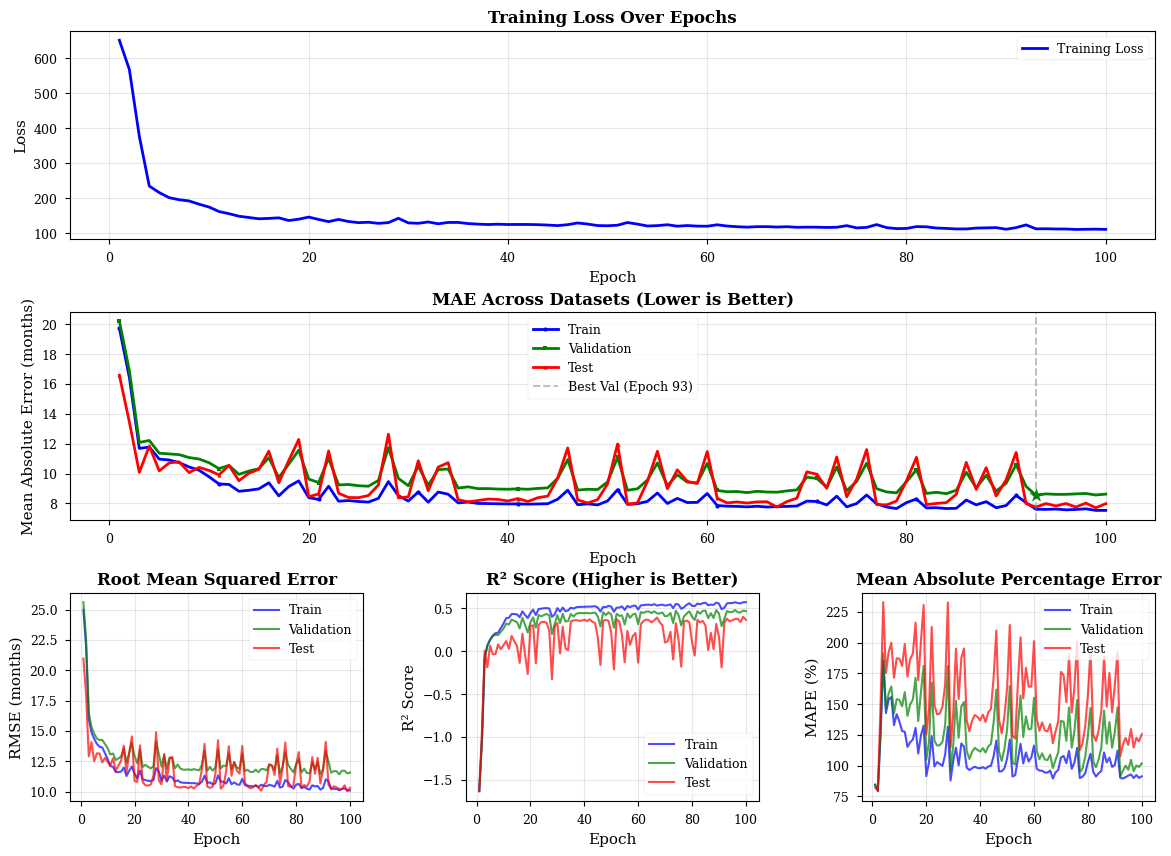

In [9]:


# Set style for good-quality plots  
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

# Create figure with multiple subplots
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35)

epochs = range(1, len(train_loss) + 1)

# ============= Plot 1: Training Loss =============
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Over Epochs', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# ============= Plot 2: MAE Comparison =============
ax2 = fig.add_subplot(gs[1, :])
train_mae = [m['mae'] for m in metrics_train]
val_mae = [m['mae'] for m in metrics_val]
test_mae = [m['mae'] for m in metrics_test]

ax2.plot(epochs, train_mae, 'b-', linewidth=2, label='Train', marker='o', markersize=3, markevery=10)
ax2.plot(epochs, val_mae, 'g-', linewidth=2, label='Validation', marker='s', markersize=3, markevery=10)
ax2.plot(epochs, test_mae, 'r-', linewidth=2, label='Test', marker='^', markersize=3, markevery=10)

# Mark best validation epoch
best_epoch = np.argmin(val_mae)
ax2.axvline(x=best_epoch+1, color='gray', linestyle='--', alpha=0.5, label=f'Best Val (Epoch {best_epoch+1})')
ax2.scatter([best_epoch+1], [val_mae[best_epoch]], color='g', s=100, zorder=5, marker='*')

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error (months)')
ax2.set_title('MAE Across Datasets (Lower is Better)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

# ============= Plot 3: RMSE =============
ax3 = fig.add_subplot(gs[2, 0])
train_rmse = [m['rmse'] for m in metrics_train]
val_rmse = [m['rmse'] for m in metrics_val]
test_rmse = [m['rmse'] for m in metrics_test]

ax3.plot(epochs, train_rmse, 'b-', linewidth=1.5, label='Train', alpha=0.7)
ax3.plot(epochs, val_rmse, 'g-', linewidth=1.5, label='Validation', alpha=0.7)
ax3.plot(epochs, test_rmse, 'r-', linewidth=1.5, label='Test', alpha=0.7)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('RMSE (months)')
ax3.set_title('Root Mean Squared Error', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='best')

# ============= Plot 4: R² Score =============
ax4 = fig.add_subplot(gs[2, 1])
train_r2 = [m['r2'] for m in metrics_train]
val_r2 = [m['r2'] for m in metrics_val]
test_r2 = [m['r2'] for m in metrics_test]

ax4.plot(epochs, train_r2, 'b-', linewidth=1.5, label='Train', alpha=0.7)
ax4.plot(epochs, val_r2, 'g-', linewidth=1.5, label='Validation', alpha=0.7)
ax4.plot(epochs, test_r2, 'r-', linewidth=1.5, label='Test', alpha=0.7)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('R² Score')
ax4.set_title('R² Score (Higher is Better)', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='best')

# ============= Plot 5: MAPE =============
ax5 = fig.add_subplot(gs[2, 2])
train_mape = [m['mape'] for m in metrics_train]
val_mape = [m['mape'] for m in metrics_val]
test_mape = [m['mape'] for m in metrics_test]

ax5.plot(epochs, train_mape, 'b-', linewidth=1.5, label='Train', alpha=0.7)
ax5.plot(epochs, val_mape, 'g-', linewidth=1.5, label='Validation', alpha=0.7)
ax5.plot(epochs, test_mape, 'r-', linewidth=1.5, label='Test', alpha=0.7)
ax5.set_xlabel('Epoch')
ax5.set_ylabel('MAPE (%)')
ax5.set_title('Mean Absolute Percentage Error', fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.legend(loc='best')

# Save the figure
plt.savefig('training_results_comprehensive_transformer.pdf', bbox_inches='tight', dpi=300)
# plt.show()





## Best Model Evaluation Graphs

Makes a figure with bar plots comparing the best model's final metrics (MAE, RMSE, R² Score, MAPE) across train, validation, and test sets, and a scatter plot of predicted vs actual for the test set.

Saved: final_performance_comparison_transformer.pdf


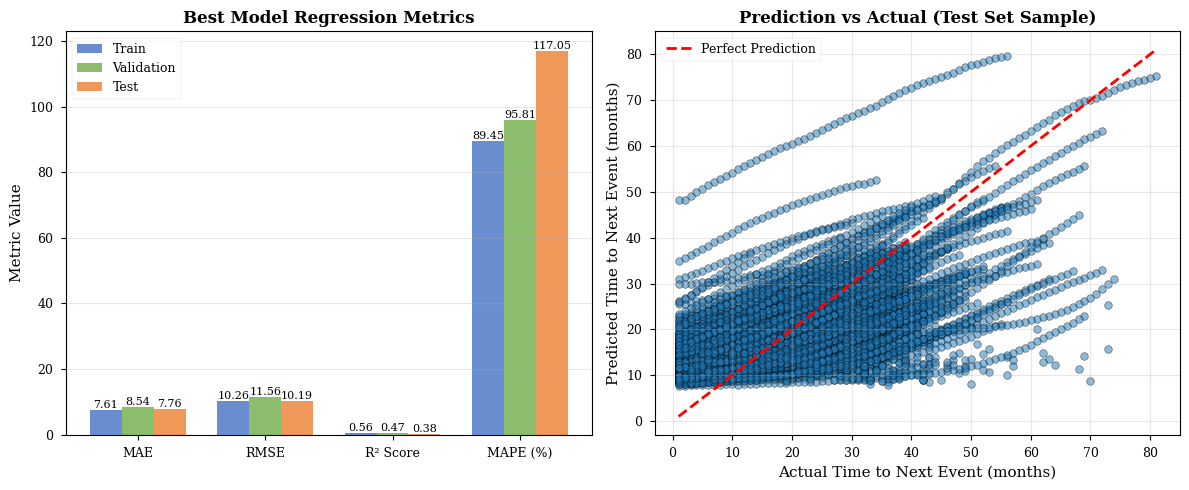

In [10]:


# ============= Create a second figure: Final Performance Comparison =============
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot comparing final metrics
metric_names = ['MAE', 'RMSE', 'R² Score', 'MAPE (%)']
train_final = [best_metrics[0]['mae'], best_metrics[0]['rmse'], 
            best_metrics[0]['r2'], best_metrics[0]['mape']]
val_final = [best_metrics[1]['mae'], best_metrics[1]['rmse'], 
            best_metrics[1]['r2'], best_metrics[1]['mape']]
test_final = [best_metrics[2]['mae'], best_metrics[2]['rmse'], 
            best_metrics[2]['r2'], best_metrics[2]['mape']]

x = np.arange(len(metric_names))
width = 0.25

bars1 = ax1.bar(x - width, train_final, width, label='Train', color='#4472C4', alpha=0.8)
bars2 = ax1.bar(x, val_final, width, label='Validation', color='#70AD47', alpha=0.8)
bars3 = ax1.bar(x + width, test_final, width, label='Test', color='#ED7D31', alpha=0.8)

ax1.set_ylabel('Metric Value')
ax1.set_title('Best Model Regression Metrics', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# Scatter plot: Predicted vs Actual (using test set samples)
best_model.eval()
with torch.no_grad():
    sample_preds = []
    sample_targets = []
    for batch_graphs in test_batches[:5]:  # First 5 batches for visualization
        graphs = []
        all_target_edges = []
        all_time_targets = []
        
        for (data, target_edges, time_targets) in batch_graphs:
            graphs.append(data)
            all_target_edges.append(target_edges)
            all_time_targets.append(time_targets)
        
        batched_data = Batch.from_data_list(graphs).to(args['device'])
        
        batch_targets = []
        batch_time_values = []
        cum_spatial_offset = 0
        cum_time_offset = 0
        
        for idx, (data, target_edges, time_targets) in enumerate(zip(graphs, all_target_edges, all_time_targets)):
            target_offset = target_edges.clone()
            target_offset[0] += cum_time_offset
            target_offset[1] += cum_spatial_offset
            batch_targets.append(target_offset)
            batch_time_values.append(time_targets)
            cum_spatial_offset += data['spatial'].x.shape[0]
            cum_time_offset += data['time'].x.shape[0]
        
        x_target = torch.cat(batch_targets, dim=1).to(args['device'])
        y_targets = torch.cat(batch_time_values).view(-1, 1).to(args['device'])
        
        edge_attr_dict = {}
        for key in batched_data.edge_types:
            if 'edge_attr' in batched_data[key] and batched_data[key].edge_attr is not None:
                edge_attr_dict[key] = batched_data[key].edge_attr
            else:
                edge_attr_dict[key] = torch.ones((batched_data[key].edge_index.shape[1], 1), device=args['device'])
        
        preds = best_model(batched_data.x_dict, batched_data.edge_index_dict, x_target, edge_attr_dict)
        sample_preds.append(preds.cpu())
        sample_targets.append(y_targets.cpu())

sample_preds = torch.cat(sample_preds).numpy().flatten()
sample_targets = torch.cat(sample_targets).numpy().flatten()

ax2.scatter(sample_targets, sample_preds, alpha=0.5, s=30, edgecolors='k', linewidths=0.5)

# Add perfect prediction line
min_val = min(sample_targets.min(), sample_preds.min())
max_val = max(sample_targets.max(), sample_preds.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax2.set_xlabel('Actual Time to Next Event (months)')
ax2.set_ylabel('Predicted Time to Next Event (months)')
ax2.set_title('Prediction vs Actual (Test Set Sample)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_performance_comparison_transformer.pdf', bbox_inches='tight', dpi=300)
print("Saved: final_performance_comparison_transformer.pdf")
# plt.show()





## Metric Graphs
This section creates a figure of MAE over epochs for train, validation, and test sets, and a histogram of residuals from test set predictions

Saved: residual_analysis_regression.pdf

TRAINING COMPLETE - REGRESSION MODEL
Best Model Performance:
  Train MAE: 7.608 months
  Val MAE: 8.539 months
  Test MAE: 7.757 months
  Test RMSE: 10.194 months
  Test R²: 0.377
  Test MAPE: 117.05%


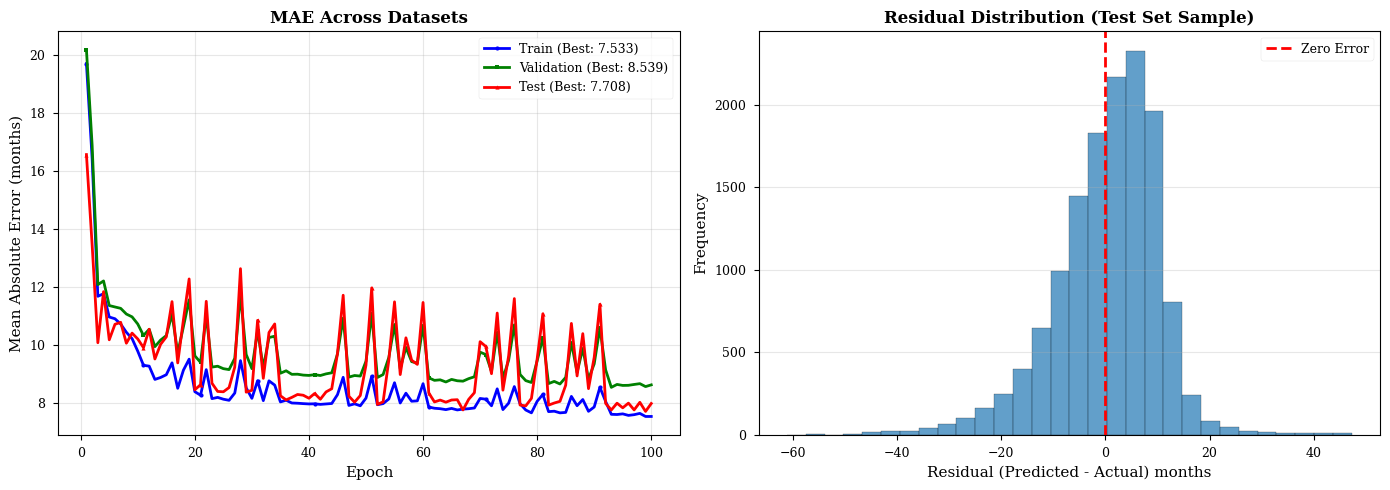

In [11]:


# ============= Create a third figure: Residual Analysis =============
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MAE over epochs
train_mae = [m['mae'] for m in metrics_train]
val_mae = [m['mae'] for m in metrics_val]
test_mae = [m['mae'] for m in metrics_test]

ax1.plot(epochs, train_mae, 'b-', linewidth=2, label=f"Train (Best: {min(train_mae):.3f})", 
        marker='o', markersize=3, markevery=10)
ax1.plot(epochs, val_mae, 'g-', linewidth=2, label=f"Validation (Best: {min(val_mae):.3f})", 
        marker='s', markersize=3, markevery=10)
ax1.plot(epochs, test_mae, 'r-', linewidth=2, label=f"Test (Best: {min(test_mae):.3f})", 
        marker='^', markersize=3, markevery=10)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean Absolute Error (months)')
ax1.set_title('MAE Across Datasets', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot 2: Residual histogram
residuals = sample_preds - sample_targets
ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax2.set_xlabel('Residual (Predicted - Actual) months')
ax2.set_ylabel('Frequency')
ax2.set_title('Residual Distribution (Test Set Sample)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('residual_analysis_regression.pdf', bbox_inches='tight', dpi=300)
print("Saved: residual_analysis_regression.pdf")
# plt.show()

print("\n" + "="*60)
print("TRAINING COMPLETE - REGRESSION MODEL")
print("="*60)
print(f"Best Model Performance:")
print(f"  Train MAE: {best_metrics[0]['mae']:.3f} months")
print(f"  Val MAE: {best_metrics[1]['mae']:.3f} months")
print(f"  Test MAE: {best_metrics[2]['mae']:.3f} months")
print(f"  Test RMSE: {best_metrics[2]['rmse']:.3f} months")
print(f"  Test R²: {best_metrics[2]['r2']:.3f}")
print(f"  Test MAPE: {best_metrics[2]['mape']:.2f}%")